### `player_role` Classification (Use case D)
#### Foundation model: What role was this player performing from movement alone?

**Pipeline:** Raw `pffScoutingData.csv` + `tracking_parquets/week*.parquet` → features we engineer → model we train → saved artifacts.

##### EDA results
| Fact | Value |
|---|---|
| PFF rows | 188,254 × 15 |
| Tracking | 8 weeks, ~1.1M rows/week, 10 Hz |
| Role counts | Coverage 57,765 · Pass Block 46,057 · Pass Route 39,513 · Pass Rush 36,362 · Pass 8,557 |
| Snap events | `ball_snap`, `autoevent_ballsnap` |
| End events | `pass_forward`, `autoevent_passforward`, `qb_sack`, `qb_strip_sack`, `pass_tipped`, `fumble` |

#### Design constraint
Features must be **self-movement only**: speed, acceleration, orientation, displacement.
Using `pff_role` or any derivative as an input would be circular.

##### Step 1: System setup

In [4]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
import joblib

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (9, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
NAVY, GOLD, GREEN, RED, AMBER = "#1B3A6B", "#C9A84C", "#2D6A4F", "#9B1C1C", "#B45309"
RANDOM_STATE = 42


ROOT         = Path.cwd().parent
PFF_PATH     = ROOT / "data" / "pffScoutingData.csv"
TRACKING_DIR = ROOT / "data" / "tracking_parquets"
ARTIFACT_DIR = ROOT / "artifacts" / "player_role"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Window boundary events
SNAP_EVENTS = {"ball_snap", "autoevent_ballsnap"}
END_EVENTS  = {"pass_forward", "autoevent_passforward",
               "qb_sack", "qb_strip_sack", "pass_tipped", "fumble"}
TRACKING_FPS = 10

print(f"PFF path     : {PFF_PATH}")
print(f"Tracking dir : {TRACKING_DIR}")

PFF path     : /Users/blecktita/PRUEBA/Akkodis/data/pffScoutingData.csv
Tracking dir : /Users/blecktita/PRUEBA/Akkodis/data/tracking_parquets


<!-- CONCLUSION_CELL_1 -->

##### Step 2: Load raw data

In [2]:
# Load PFF scouting CSV 
pff = pd.read_csv(PFF_PATH, na_values=["NA"])
print(f"PFF shape  : {pff.shape}   ← expect (188254, 15)")
print(f"Roles      : {pff['pff_role'].value_counts().to_dict()}")

PFF shape  : (188254, 15)   ← expect (188254, 15)
Roles      : {'Coverage': 57765, 'Pass Block': 46057, 'Pass Route': 39513, 'Pass Rush': 36362, 'Pass': 8557}


In [3]:
# Load all 8 tracking weeks

KEEP_COLS = ["gameId", "playId", "nflId", "frameId",
             "x", "y", "s", "a", "dis", "o", "dir", "event"]

weeks = []
for i in range(1, 9):
    w = pd.read_parquet(
        TRACKING_DIR / f"week{i}.parquet",
        engine="pyarrow",
        columns=KEEP_COLS
    )
    w["week"] = i
    weeks.append(w)
    print(f"  week{i}: {len(w):,} rows")

tracking = pd.concat(weeks, ignore_index=True)

# Drop football rows (nflId is NaN for the ball)
tracking = tracking.dropna(subset=["nflId"]).copy()
tracking["nflId"] = tracking["nflId"].astype(int)

print(f"\nAll weeks combined : {len(tracking):,} player rows")
print(f"Unique games       : {tracking['gameId'].nunique()}")

  week1: 1,118,122 rows
  week2: 1,042,774 rows
  week3: 560,908 rows
  week4: 560,917 rows
  week5: 1,074,606 rows
  week6: 1,097,813 rows
  week7: 973,797 rows
  week8: 1,885,241 rows

All weeks combined : 7,952,692 player rows
Unique games       : 122


<!-- CONCLUSION_CELL_2 -->

##### Step 3: Build snap-to-event windows

In [ ]:
# Build play windows from snap → first end-event
# SNAP_EVENTS mark the start; END_EVENTS mark the end.
def build_play_windows(tracking: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame with (gameId, playId, snap_frame, end_frame)."""
    rows = []
    for (gid, pid), grp in tracking.groupby(["gameId", "playId"]):
        events = grp[["frameId", "event"]].drop_duplicates("frameId")

        snap_frames = events.loc[
            events["event"].isin(SNAP_EVENTS), "frameId"
        ]
        if snap_frames.empty:
            continue
        snap_frame = snap_frames.min()

        end_frames = events.loc[
            (events["event"].isin(END_EVENTS)) &
            (events["frameId"] > snap_frame), "frameId"
        ]
        end_frame = end_frames.min() if not end_frames.empty else events["frameId"].max()

        rows.append({"gameId": gid, "playId": pid,
                     "snap_frame": snap_frame, "end_frame": end_frame})

    return pd.DataFrame(rows)


windows = build_play_windows(tracking)
print(f"Windows built : {len(windows):,} plays")
print(windows.head())

Windows built : 8,533 plays
       gameId  playId  snap_frame  end_frame
0  2021090900      97           6         38
1  2021090900     137           6         32
2  2021090900     187           6         26
3  2021090900     282           6         38
4  2021090900     349           6         32


##### Step 4: engineer self-movement features



In [6]:
# Join tracking to windows, restrict to snap→end frames
# For each player on each play, aggregate tracking signals over the snap-to-event window.

windowed = tracking.merge(windows, on=["gameId", "playId"], how="inner")
windowed = windowed[
    (windowed["frameId"] >= windowed["snap_frame"]) &
    (windowed["frameId"] <= windowed["end_frame"])
].copy()

print(f"Windowed rows: {len(windowed):,}")

Windowed rows: 6,097,366


In [7]:
# Aggregate per player-play into movement features
# All features are derived from the player's own tracking columns.
# o = orientation (body facing), dir = travel direction.
# o_dir_delta: gap between facing and moving: large for backpedaling CBs.

def engineer_self_movement(windowed: pd.DataFrame) -> pd.DataFrame:
    """Aggregate tracking signals per (gameId, playId, nflId)."""

    def agg_player(grp):
        grp = grp.sort_values("frameId")
        n = len(grp)

        # Displacement: straight-line distance from first to last frame
        dx = grp["x"].iloc[-1] - grp["x"].iloc[0]
        dy = grp["y"].iloc[-1] - grp["y"].iloc[0]
        displacement = np.sqrt(dx**2 + dy**2)

        # Gap between body orientation and travel direction
        o_dir_delta = np.abs(
            ((grp["o"] - grp["dir"]) + 180) % 360 - 180
        ).mean()

        return pd.Series({
            "n_frames"         : n,
            "window_duration_s": n / TRACKING_FPS,
            "speed_mean"       : grp["s"].mean(),
            "speed_max"        : grp["s"].max(),
            "speed_std"        : grp["s"].std(ddof=0),
            "accel_mean"       : grp["a"].mean(),
            "accel_max"        : grp["a"].max(),
            "distance_covered" : grp["dis"].sum(),
            "displacement"     : displacement,
            "orientation_std"  : grp["o"].std(ddof=0),
            "dir_std"          : grp["dir"].std(ddof=0),
            "o_dir_delta_mean" : o_dir_delta,
        })

    feats = (
        windowed
        .groupby(["gameId", "playId", "nflId"])
        .apply(agg_player)
        .reset_index()
    )
    return feats


movement = engineer_self_movement(windowed)
print(f"Movement feature rows : {len(movement):,}")
print(movement.dtypes.to_string())

Movement feature rows : 187,726
gameId                 int64
playId                 int64
nflId                  int64
n_frames             float64
window_duration_s    float64
speed_mean           float64
speed_max            float64
speed_std            float64
accel_mean           float64
accel_max            float64
distance_covered     float64
displacement         float64
orientation_std      float64
dir_std              float64
o_dir_delta_mean     float64


In [8]:
# Join movement features to PFF labels
# pff_role is the target. gameId/playId/nflId are the join keys.

VALID_ROLES = {"Coverage", "Pass Block", "Pass Route", "Pass Rush", "Pass"}

pff_roles = pff[["gameId", "playId", "nflId", "pff_role"]].copy()
pff_roles = pff_roles[pff_roles["pff_role"].isin(VALID_ROLES)]

role_features = movement.merge(pff_roles, on=["gameId", "playId", "nflId"], how="inner")

print(f"Final feature table : {role_features.shape}")
print()
print("Label distribution:")
print(role_features["pff_role"].value_counts().to_string())

Final feature table : (187726, 16)

Label distribution:
pff_role
Coverage      57600
Pass Block    45932
Pass Route    39398
Pass Rush     36263
Pass           8533


##### Step 5: Prepare Model Input

In [9]:
# Feature columns and target
TARGET = "pff_role"

FEATURE_COLS = [
    "speed_mean",        # average speed: pass rushers move faster than linemen
    "speed_max",         # peak speed
    "speed_std",         # speed variability
    "accel_mean",        # average acceleration
    "accel_max",         # peak acceleration
    "distance_covered",  # total path length
    "displacement",      # net distance snap to end
    "orientation_std",   # body-facing variability: high for CBs backpedaling
    "dir_std",           # travel direction variability
    "o_dir_delta_mean",  # facing vs moving gap: key backpedal signal
    "window_duration_s", # play length
]

# Encode target to integers for sklearn
le = LabelEncoder()
role_features["label"] = le.fit_transform(role_features[TARGET])
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)

print(f"Features : {FEATURE_COLS}")
print(f"Classes  : {CLASS_NAMES}")
print()
print(role_features[FEATURE_COLS].describe().round(3).to_string())

Features : ['speed_mean', 'speed_max', 'speed_std', 'accel_mean', 'accel_max', 'distance_covered', 'displacement', 'orientation_std', 'dir_std', 'o_dir_delta_mean', 'window_duration_s']
Classes  : ['Coverage', 'Pass', 'Pass Block', 'Pass Route', 'Pass Rush']

       speed_mean   speed_max   speed_std  accel_mean   accel_max  distance_covered  displacement  orientation_std     dir_std  o_dir_delta_mean  window_duration_s
count  187726.000  187726.000  187726.000  187726.000  187726.000        187726.000    187726.000       187726.000  187726.000        187726.000         187726.000
mean        2.643       4.477       1.375       1.898       3.736             8.877         7.609           42.548      45.919            77.927              3.248
std         1.203       1.826       0.668       0.690       1.411             5.970         5.229           38.489      37.645            44.132              1.273
min         0.000       0.000       0.000       0.000       0.000             0.030 

##### Step 6: Train / Test Split

In [10]:
# Group split by gameId
# Same game = same players + same scheme = correlated rows.
# GroupShuffleSplit keeps all rows from one game in the same fold.

X      = role_features[FEATURE_COLS].values
y      = role_features["label"].values
groups = role_features["gameId"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

train_games = set(groups[train_idx])
test_games  = set(groups[test_idx])

print(f"Train : {len(X_train):,} rows  ({len(train_games)} games)")
print(f"Test  : {len(X_test):,} rows  ({len(test_games)} games)")
print(f"Game overlap (must be 0) : {len(train_games & test_games)}")

Train : 149,380 rows  (97 games)
Test  : 38,346 rows  (25 games)
Game overlap (must be 0) : 0


##### Step 7: Baseline

In [11]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
dummy_f1 = f1_score(y_test, y_dummy, average="macro", zero_division=0)
print(f"Baseline Macro-F1 : {dummy_f1:.4f}")

Baseline Macro-F1 : 0.1966


##### Step 8: Logistic Regression (Interpretable Benchmark)

In [12]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight = "balanced",
        max_iter     = 1000,
        random_state = RANDOM_STATE,
    ))
])
lr_pipe.fit(X_train, y_train)
y_lr   = lr_pipe.predict(X_test)
lr_f1  = f1_score(y_test, y_lr, average="macro", zero_division=0)
print(f"LR Macro-F1  : {lr_f1:.4f}   (baseline={dummy_f1:.4f})")

LR Macro-F1  : 0.6608   (baseline=0.1966)


##### Step 9: HistGradientBoosting (Cross-Validated & Tuned)

In [43]:
# HistGradientBoostingClassifier — GroupKFold cross-validated hyperparameter search.
# class_weight='balanced': handles class size differences across 5 roles.
# early_stopping picks the iteration count per fit, so max_iter is not searched.
# CV runs only on the TRAIN split — the held-out test set below stays untouched
# for every downstream metric (evaluation, SHAP, error analysis).

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

cv = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "max_depth"        : randint(3, 7),
    "learning_rate"    : uniform(0.02, 0.13),   # 0.02–0.15
    "min_samples_leaf" : randint(10, 50),
    "max_leaf_nodes"   : randint(15, 63),
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train, groups=groups[train_idx])

hgbt        = search.best_estimator_
cv_score_mean = search.best_score_
cv_score_std  = search.cv_results_["std_test_score"][search.best_index_]

print(f"Best params    : {search.best_params_}")
print(f"CV Macro-F1    : {cv_score_mean:.4f} ± {cv_score_std:.4f}  (5-fold, grouped by gameId)")

y_pred   = hgbt.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Iterations     : {hgbt.n_iter_}")
print(f"HGBT Macro-F1  : {macro_f1:.4f}   (LR={lr_f1:.4f}, baseline={dummy_f1:.4f})  ← held-out test set")

Best params    : {'learning_rate': np.float64(0.04703241617286455), 'max_depth': 6, 'max_leaf_nodes': 43, 'min_samples_leaf': 27}
CV Macro-F1    : 0.7767 ± 0.0057  (5-fold, grouped by gameId)
Iterations     : 500
HGBT Macro-F1  : 0.7881   (LR=0.6608, baseline=0.1966)  ← held-out test set


##### Step 10: Evaluation

In [44]:
print("Per-class classification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

Per-class classification report:
              precision    recall  f1-score   support

    Coverage       0.86      0.78      0.82     11762
        Pass       0.52      0.80      0.63      1743
  Pass Block       0.85      0.83      0.84      9357
  Pass Route       0.83      0.83      0.83      8073
   Pass Rush       0.80      0.84      0.82      7411

    accuracy                           0.82     38346
   macro avg       0.77      0.82      0.79     38346
weighted avg       0.83      0.82      0.82     38346



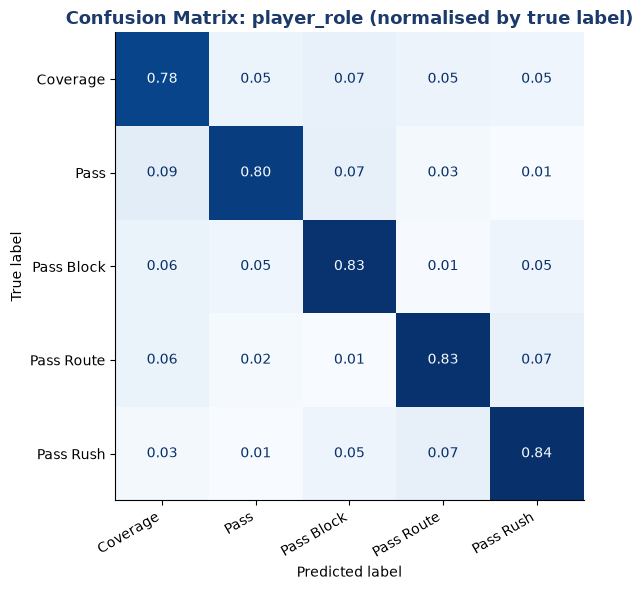

In [45]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".2f"
)
ax.set_title("Confusion Matrix: player_role (normalised by true label)",
             fontsize=13, fontweight="bold", color=NAVY)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

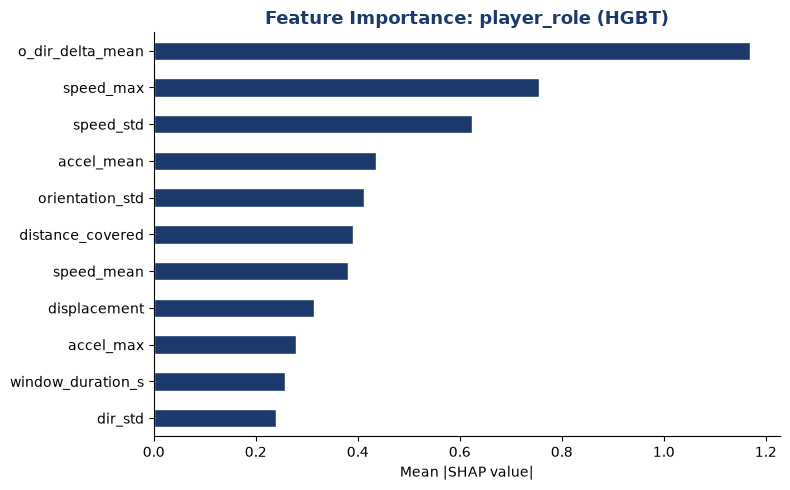

o_dir_delta_mean     1.169405
speed_max            0.756328
speed_std            0.624628
accel_mean           0.434896
orientation_std      0.411535
distance_covered     0.391322
speed_mean           0.380660
displacement         0.314717
accel_max            0.278338
window_duration_s    0.257105
dir_std              0.239841


In [46]:
import shap
explainer = shap.TreeExplainer(hgbt)
shap_values = explainer.shap_values(X_test)
importance = pd.Series(
    np.abs(shap_values).mean(axis=(0, 2)),
    index=FEATURE_COLS, name="importance"
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color=NAVY, edgecolor="white")
ax.set_title("Feature Importance: player_role (HGBT)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False).to_string())

##### Step 12: Error Analysis

In [47]:
# Which roles are hardest to separate?
test_df = role_features.iloc[test_idx].copy()
test_df["y_pred"]  = le.inverse_transform(y_pred)
test_df["correct"] = test_df["pff_role"] == test_df["y_pred"]

error_rate = (
    test_df.groupby("pff_role")["correct"]
    .agg(error_rate=lambda x: 1 - x.mean(), n="count")
    .sort_values("error_rate", ascending=False)
)
print("Error rate per true role:")
print(error_rate.to_string())
print()

# Most common misclassification pairs
errors = test_df[~test_df["correct"]]
print("Top confusion pairs (true → predicted):")
print(
    errors.groupby(["pff_role", "y_pred"])
    .size()
    .sort_values(ascending=False)
    .head(8)
    .to_string()
)

Error rate per true role:
            error_rate      n
pff_role                     
Coverage      0.223091  11762
Pass          0.203098   1743
Pass Block    0.169178   9357
Pass Route    0.165118   8073
Pass Rush     0.156254   7411

Top confusion pairs (true → predicted):
pff_role    y_pred    
Coverage    Pass Block    817
            Pass Route    644
            Pass          624
Pass Route  Pass Rush     589
Pass Block  Coverage      580
Pass Rush   Pass Route    551
Coverage    Pass Rush     539
Pass Route  Coverage      507


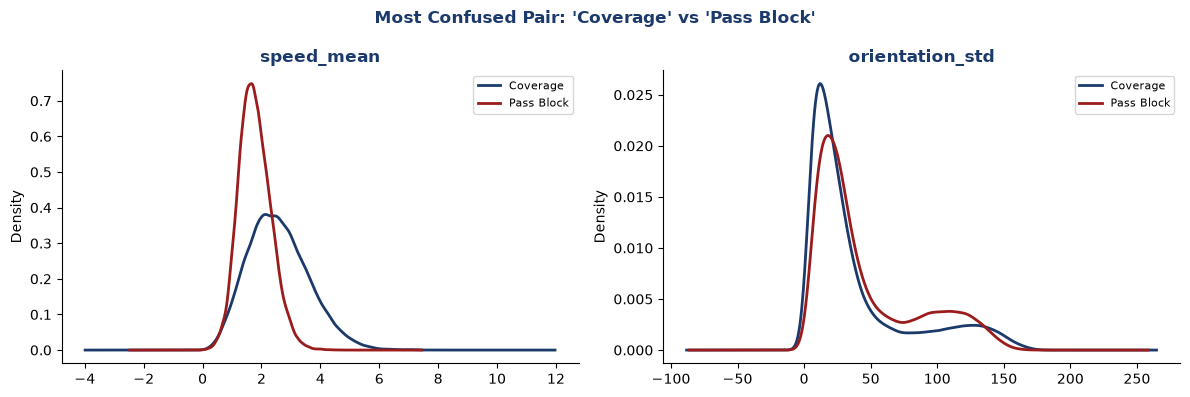

In [48]:
# KDE: most confused pair: do they move alike?
top_pair = (
    errors.groupby(["pff_role", "y_pred"]).size().idxmax()
)
role_a, role_b = top_pair

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, ["speed_mean", "orientation_std"]):
    for role, color in [(role_a, NAVY), (role_b, RED)]:
        role_features[role_features["pff_role"] == role][feat]\
            .plot.kde(ax=ax, color=color, lw=2, label=role)
    ax.set_title(feat, fontweight="bold", color=NAVY)
    ax.legend(fontsize=8)
plt.suptitle(f"Most Confused Pair: '{role_a}' vs '{role_b}'",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

##### Step 13: Save Artifacts & Summary

In [49]:
import json

joblib.dump(hgbt,    ARTIFACT_DIR / "model.joblib")
joblib.dump(lr_pipe, ARTIFACT_DIR / "lr_model.joblib")
joblib.dump(le,      ARTIFACT_DIR / "label_encoder.joblib")

role_features.to_parquet(ARTIFACT_DIR / "feature_table.parquet", index=False)

# Use the SHAP importance Series computed earlier
pd.DataFrame({"feature": FEATURE_COLS,
              "importance": importance.reindex(FEATURE_COLS).values})\
  .sort_values("importance", ascending=False)\
  .to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)

report = classification_report(
    y_test, y_pred, target_names=CLASS_NAMES,
    zero_division=0, output_dict=True
)
# search.best_params_ holds numpy scalar types (from randint/uniform) — cast to
# native python so json.dump doesn't choke on them.
best_params_json = {k: (v.item() if hasattr(v, "item") else v)
                     for k, v in search.best_params_.items()}
metrics = {
    "macro_f1"      : round(macro_f1, 4),
    "lr_macro_f1"   : round(lr_f1, 4),
    "baseline_f1"   : round(dummy_f1, 4),
    "cv_score_mean" : round(float(cv_score_mean), 4),
    "cv_score_std"  : round(float(cv_score_std), 4),
    "cv_scoring"    : "f1_macro",
    "best_params"   : best_params_json,
    "n_train"       : int(len(X_train)),
    "n_test"        : int(len(X_test)),
    "n_classes"     : N_CLASSES,
    "class_names"   : CLASS_NAMES,
    "per_class_f1"  : {c: round(report[c]["f1-score"], 4) for c in CLASS_NAMES},
}
with open(ARTIFACT_DIR / "metrics_report.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved to:", ARTIFACT_DIR)
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {p.name}")

Saved to: /Users/blecktita/PRUEBA/Akkodis/artifacts/player_role
  feature_importance.csv
  feature_table.parquet
  label_encoder.joblib
  lr_model.joblib
  metrics_report.json
  model.joblib


In [50]:
print("═" * 55)
print("Player_role RESULTS SUMMARY")
print("═" * 55)
print(f"  Feature rows    : {len(role_features):,}")
print(f"  Features built  : {len(FEATURE_COLS)} self-movement cols")
print(f"  Classes         : {CLASS_NAMES}")
print()
print(f"  Baseline Macro-F1 : {dummy_f1:.4f}")
print(f"  LR Macro-F1       : {lr_f1:.4f}")
print(f"  HGBT Macro-F1     : {macro_f1:.4f}  ← primary metric")
print()
print("  Per-class F1:")
for cls in CLASS_NAMES:
    f1 = report[cls]["f1-score"]
    bar = "*" * int(f1 * 20)
    print(f"    {cls:<20} {bar:<20} {f1:.3f}")

═══════════════════════════════════════════════════════
Player_role RESULTS SUMMARY
═══════════════════════════════════════════════════════
  Feature rows    : 187,726
  Features built  : 11 self-movement cols
  Classes         : ['Coverage', 'Pass', 'Pass Block', 'Pass Route', 'Pass Rush']

  Baseline Macro-F1 : 0.1966
  LR Macro-F1       : 0.6608
  HGBT Macro-F1     : 0.7881  ← primary metric

  Per-class F1:
    Coverage             ****************     0.818
    Pass                 ************         0.629
    Pass Block           ****************     0.840
    Pass Route           ****************     0.834
    Pass Rush            ****************     0.820


<!-- CONCLUSION_CELL_11 -->